## Entrainnement du modèle

*Rappel des contraintes :*

* Puissance de calcul limitée
* Taille du dataset très petite (200 images par classe)
* Favoriser le Recall car on souhaite éviter les faux négatif

| Architecture | Avantages | Inconvénients | Cas d’usage idéal |
| --- | --- | --- | --- |
| ResNet50 | Robuste, profond, bon transfer | Lourd (25M params) | Baseline solide |
| EfficientNetB0 | Léger, bon compromis performance/taille | Moins profond que ResNet | Ressources limitées |
| VGG16 | Simple, facile à implémenter | Très lourd (138M params), lent | Baseline historique |
| MobileNetV3 | Ultra-léger, optimisé mobile | Moins précis sur tâches complexes | Edge devices |
| DenseNet121 | Connexions denses → moins de params | Mémoire GPU élevée | Features réutilisées efficacement |

Stratégie d'entrainnement :
On va commencer par évaluer un EfficientNetB2 et un MobileNetV3, afin de contrôler si il réussi a converger. Dans le cas inverse nous essayerons des modèles plus lourd.

Nous allons favoriser les méthodes de transfert learning qui faciliterons et accèlererons l'entrainnement des modèles

In [109]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
import torch

device = torch.device('cuda') # Ne pas mettre de if car sinon ne fonctionne pas (pourquoi, je ne sais pas)
torch.backends.cudnn.benchmark = True
print(device)

# Choix du modèle
CHECKPOINT_PATH = "./saved_models"
Model_choices = "Resnet"

cuda


### Préparation des données

In [110]:
df = pd.read_pickle('data_preprocess.pkl')
print(df.head())
print(df.shape)

le = LabelEncoder()
y = le.fit_transform(df['Class'])  # Convertit en entiers
y = y.astype(np.int64) 
# 1. Extraire les données du DataFrame
X = np.stack(df['img_preprocess'].values)  # Forme attendue : (N, C, H, W) ou (N, H, W, C)

# 2. Vérifier la forme de X et ajuster si nécessaire (ex: passer de (N, H, W, C) à (N, C, H, W))
if X.shape[-1] == 3:  # Si les images sont en (H, W, C)
    X = np.transpose(X, (0, 3, 1, 2))  # Passer à (N, C, H, W)

# 3. Convertir en tenseurs PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)  # float32 pour les images
y_tensor = torch.tensor(y, dtype=torch.long)    # long pour les classes

# 4. Créer le Dataset
full_dataset = TensorDataset(X_tensor, y_tensor)

# 5. Séparer en train/val (160 train, 40 val)
generator = torch.Generator().manual_seed(42)  # Pour la reproductibilité
train_set, val_set = random_split(full_dataset, [683, 171], generator=generator)

# 6. Créer les DataLoader
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)  # Pas de shuffle pour la validation

# 7. Vérification rapide
print("Nombre de lots dans train_loader :", len(train_loader))
print("Nombre de lots dans val_loader :", len(val_loader))

       Class                                     img_preprocess
0  Abrasions  [[[tensor(0.5529), tensor(0.5373), tensor(0.55...
1  Abrasions  [[[tensor(0.2000), tensor(0.2000), tensor(0.20...
2  Abrasions  [[[tensor(0.2863), tensor(0.2863), tensor(0.28...
3  Abrasions  [[[tensor(0.6078), tensor(0.6157), tensor(0.62...
4  Abrasions  [[[tensor(0.4196), tensor(0.4039), tensor(0.37...
(854, 2)
Nombre de lots dans train_loader : 22
Nombre de lots dans val_loader : 6


### Configuration du modèle

In [111]:
# # Définir le modèle (Resnet or Efficientnet)

## Si EfficientNet -----------------------------------------------------------------
model_ef = models.efficientnet_b0(pretrained=True)
for param in model_ef.parameters():
    param.requires_grad = False  # Geler toutes les couches

# Remplacer la tête (classification layer)
num_features = model_ef.classifier[1].in_features
model_ef.classifier[1] = torch.nn.Linear(num_features, 7).to(device)

## Si Resnet -----------------------------------------------------------------
model_res = models.resnet50(pretrained=True)
for param in model_res.parameters():
    param.requires_grad = False  # Geler toutes les couches
model_res.fc = torch.nn.Linear(model_res.fc.in_features, 7)  # Remplacer la tête

if Model_choices == "Resnet" :
    model = model_res
elif Model_choices == "Efficientnet":
    model = model_ef

model = model.to(device)

# Optimizer et Scheduler et fonction de perte
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
criterion = torch.nn.CrossEntropyLoss()

# Boucle d'entraînement
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step(running_loss)  # ReduceLROnPlateau attend une métrique (ici, la loss moyenne)
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    

c:\Users\USER\Desktop\Master_2_Data_Science\Deep_learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\USER\Desktop\Master_2_Data_Science\Deep_learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\USER\Desktop\Master_2_Data_Science\Deep_learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equival

Epoch 1, Loss: 1.5943
Epoch 2, Loss: 1.1005
Epoch 3, Loss: 0.8426
Epoch 4, Loss: 0.6965
Epoch 5, Loss: 0.6219
Epoch 6, Loss: 0.5865
Epoch 7, Loss: 0.5091
Epoch 8, Loss: 0.4529
Epoch 9, Loss: 0.4265
Epoch 10, Loss: 0.3900


### Sauvegarde du modèle

In [112]:
import json
def _config_path(model_path, model_name):
    ### VOTRE CODE ICI ###
    return os.path.join(model_path, f"{model_name}_config.json")  


def _weights_path(model_path, model_name):
    ### VOTRE CODE ICI ###
    return os.path.join(model_path, f"{model_name}_weights.pth")

def checkpoint_save(model, model_path, model_name):
    """
    Sauvegarde model.state_dict() et model.config (dict) en JSON.
    """
    os.makedirs(model_path, exist_ok=True)
    torch.save(model.state_dict(), _weights_path(model_path, model_name))
    if hasattr(model, "config") and isinstance(model.config, dict):
        with open(_config_path(model_path, model_name), "w", encoding="utf-8") as f:
            json.dump(model.config, f, indent=2)



checkpoint_save(model,CHECKPOINT_PATH,Model_choices)

### Evaluation du modèle

Accuracy globale: 0.8187


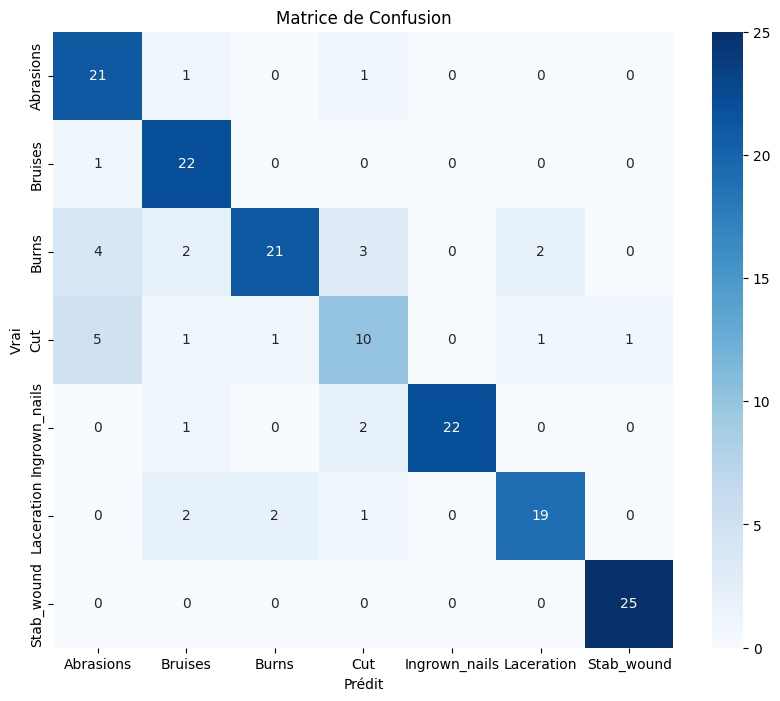

Rapport de Classification:
                precision    recall  f1-score   support

    Abrasions     0.6774    0.9130    0.7778        23
      Bruises     0.7586    0.9565    0.8462        23
        Burns     0.8750    0.6562    0.7500        32
          Cut     0.5882    0.5263    0.5556        19
Ingrown_nails     1.0000    0.8800    0.9362        25
   Laceration     0.8636    0.7917    0.8261        24
   Stab_wound     0.9615    1.0000    0.9804        25

     accuracy                         0.8187       171
    macro avg     0.8178    0.8177    0.8103       171
 weighted avg     0.8302    0.8187    0.8166       171

Abrasions: Precision=0.6774, Recall=0.9130, F1=0.7778
Bruises: Precision=0.7586, Recall=0.9565, F1=0.8462
Burns: Precision=0.8750, Recall=0.6562, F1=0.7500
Cut: Precision=0.5882, Recall=0.5263, F1=0.5556
Ingrown_nails: Precision=1.0000, Recall=0.8800, F1=0.9362
Laceration: Precision=0.8636, Recall=0.7917, F1=0.8261
Stab_wound: Precision=0.9615, Recall=1.0000, F1

In [113]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

all_labels = []
all_predicted = []
class_names = ["Abrasions","Bruises","Burns","Cut","Ingrown_nails","Laceration","Stab_wound"]

# Mode évaluation
model.eval()

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)

        # Prédictions (argmax pour la classification)
        _, predicted = torch.max(outputs, 1)

        # Stockage des résultats
        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predicted)
print(f"Accuracy globale: {accuracy:.4f}")

cm = confusion_matrix(all_labels, all_predicted)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.show()

report = classification_report(all_labels, all_predicted, target_names=class_names, digits=4)
print("Rapport de Classification:\n", report)

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predicted, average=None)
for i, class_name in enumerate(class_names):
    print(f"{class_name}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}")

### Test sur image réel

In [114]:
data_test = pd.read_pickle('data.pkl')

num_img = np.random.randint(431)

data_test_img = data_test['img'][num_img]
label_test = data_test['Class'][num_img]

def visualize_image(image):
    if isinstance(image, np.ndarray):
        img = Image.fromarray(image)

    elif isinstance(image, Image.Image):
        img = image

    elif isinstance(image, torch.Tensor):
        # C x H x W -> H x W x C
        img = image.permute(1, 2, 0).numpy()

        # dénormalisation si Normalize((0.5,), (0.5,))
        img = (img * 0.5) + 0.5

        img = (img * 255).clip(0, 255).astype(np.uint8)
        img = Image.fromarray(img)

    else:
        raise ValueError(
            f"Type non supporté : {type(image)}"
        )

    img.show()

train_transforms = transforms.Compose([
    transforms.Resize((224,224),interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(), # Transform le format en Tenseur (donc plus numpy ni Pil.Image)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def preprocess_img(image):
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image)
    img_augmented = train_transforms(image)
    return img_augmented

data_test_preprocess = preprocess_img(data_test_img).to(device)

data_test_preprocess = torch.unsqueeze(data_test_preprocess, 0)
outputs = model(data_test_preprocess)
predict_test = torch.argmax(outputs, dim=1)

visualize_image(data_test_img)
print(f'Class réel : {label_test}')

label_predict = le.inverse_transform(
    predict_test.cpu().numpy()
)[0]
print(f'Class prédite : {label_predict}')


Class réel : Stab_wound
Class prédite : Stab_wound


In [115]:
def read_file(file_path,type='RGB'):
    # Open the image file
    with Image.open(file_path) as img:
        # Convert the image to RGB (in case it's in a different format)
        img = img.convert(type)
        # Convert the image to a NumPy array
        img_array = np.array(img)

    return img_array

test = read_file(r'C:\Users\USER\Desktop\Master_2_Data_Science\Deep_learning\Projet\image_test_3.jpg')
visualize_image(test)

test = preprocess_img(test).to(device)
test = torch.unsqueeze(test, 0)

outputs = model(test)
predict_test = torch.argmax(outputs, dim=1)
label_predict = le.inverse_transform(
    predict_test.cpu().numpy()
)[0]
print(f'Class prédite : {label_predict}')

Class prédite : Bruises
